<a target="_blank" href="https://colab.research.google.com/github/robgen/HEDSpython/blob/main/Tutorial_5.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **APIs**

API stands for Application Program Interface and is a way for two or more computer programmes to communicate with each other.

REST (Representational State Transfer) APIs allow communication between a client (your program) and a server (usually online) using HTTP (HyperText Transfer Protocol) to communicate.

A HTTP request is sent from client to server containing the instructions in a file (usually .json). The server then executes the instructions and sends a HTTP response which contains the result.

Let's look at an example.

In [ ]:
import requests
import json
import pandas

We first define the HTTP request providing the appropriate URL.

In [ ]:
country = 'Italy'
daterange = '20211215-20220115'
url = ('https://covidmap.umd.edu/apiv2/resources?indicator=covid&type=smoothed&country=' +
    country + '&daterange=' + daterange )
url

We then send request via API and collect the text response using the `get()` function.

In [ ]:
response = requests.get(url, verify=False)
print(response)

We can get a number of API responses the key ones to remember are:

*   200 - success
*   400 - bad request (i.e., the error is in our code)
*   500 - internal server error (i.e., the error is on the server side)


We then transform the text response in a json file. a json is a JavaScript Object Notation consisting of name-object pairs and punctuation in the form of brackets, parentheses, semicolons and colons (basically a big dictionary!)

In [ ]:
jsonData = json.loads(response.text)
print(jsonData)

And lastly convert the json to a pandas dataframe - ready for us to use.

In [ ]:
df = pandas.DataFrame.from_dict(jsonData['data'])
df.head()

## **Using World Bank Data API**

You can find the documentation on the API interface and practical examples [here](https://wbdata.readthedocs.io/en/stable/) and [here](https://blogs.worldbank.org/opendata/accessing-world-bank-data-apis-python-r-ruby-stata) respectively.

Let's replicate the example code below.

We first need to install the `wbdata` library which contains the API call.

In [ ]:
!pip3 install -U wbdata

We then import the libraries.

In [ ]:
import wbdata
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

The `get_country()` function gives us a list of all countries.  

In [ ]:
wbdata.get_countries()

We can pick the countries that interest us.

In [ ]:
countries = ["USA","GBR","ITA"]

The `get_indicator()` function gives us a list of all indicators.

In [ ]:
wbdata.get_indicators()

We can choose the indicator that we want.

In [ ]:
indicators = {'NY.GNP.PCAP.CD':'GNI per Capita'}

We then make the call using the country and indicators parameters.

In [ ]:
df = wbdata.get_dataframe(indicators, country=countries, parse_dates=False)

In [ ]:
df

The df is given as a pivot table. Pandas' `.unstack()` method helps reshape it into something plottable.

In [ ]:
dfu = df.unstack(level=0)
dfu

We can now plot the GNI for the selected countries.

In [ ]:
dfu.plot();
plt.legend(loc='best');
plt.title("GNI Per Capita ($USD, Atlas Method)");
plt.xlabel('Date');
plt.ylabel('GNI Per Capita ($USD, Atlas Method');

We can also plot two indicators together if we want to compare their trends.
Let us see the relationship between GDP and population un China.

We first select the country and indicators of interest.

In [ ]:
chn = ['ITA']
start_year = 1990
end_year = 2021
gdp_indicator = {'NY.GDP.PCAP.CD':'GDP'}
pop_indicator = {'SP.POP.TOTL':'POP'}
co2_energy_indicator = {'CC.CO2.EMSE.EN': 'ENG'}

Then get the data by calling the World Bank Data API.

In [ ]:
gdp = wbdata.get_dataframe(gdp_indicator, country=chn, date=(str(start_year), str(end_year)))
pop = wbdata.get_dataframe(pop_indicator , country=chn, date=(str(start_year), str(end_year)))
co2_energy = wbdata.get_dataframe(co2_energy_indicator , country=chn, date=(str(start_year), str(end_year)))

To make the two indicators comparable in out plot we standardise them.

In [ ]:
gdp = (gdp-gdp.mean())/gdp.std()
pop = (pop-pop.mean())/pop.std()
co2_energy = (co2_energy-co2_energy.mean())/co2_energy.std()

And then make sure that years are in the right order.

In [ ]:
gdp = gdp.sort_index(ascending=True)
pop = pop.sort_index(ascending=True)
co2_energy = co2_energy.sort_index(ascending=True)

We then plot the two indicators.

In [ ]:
fig, ax = plt.subplots(dpi=200)
plt.rcParams.update({'font.size': 10})
fig.subplots_adjust(wspace=0)
ax.plot(gdp, linewidth=2.0, label='GDP')
ax.plot(pop, linewidth=2.0, label='POP')
ax.plot(co2_energy, linewidth=2.0, label='CO2 ENERGY')
plt.xticks(rotation='vertical')
plt.xticks(np.arange(0, 31, 5))
plt.title('GDP vs. POP vs. CO2 ENERGY in China');
plt.xlabel('year');
plt.ylabel('standardised value');
plt.legend()

# **Exercise**

Download the first 10000 violent incidents across the world reported in 2020 by the Uppsala Conflict Data Program and create plots as indicated, following examples in the past tutorials and examples contained in the plotting_example.ipynb file.

1. Familiarize yourself with the [API documentation](https://ucdp.uu.se/apidocs/), formulate a query to download the data and return the response as a dataframe following the example above.

2. After checking that you have downloaded the data correctly and what information is available, create a barchart reporting violent incidents by country.

3. Create a second barchart like the one above but using colors to differentiate types of violence. Make sure a legend and labels are present.

4. Side by side, create three histograms reporting the distribution of violent incidents by type of violence in the sample population of countries.

**Exercise 1**

In [39]:
# insert code below
import requests
import pandas as pd
import matplotlib.pyplot as plt


**Exercise 2**

In [41]:
# insert code below
# Base API URL
base_url = "https://ucdpapi.pcr.uu.se/api/gedevents/22.1/"

# Empty list where we will store all events
all_events = []

# We want data from 2020 only
year_from = 2020
year_to = 2020

# API settings
page_size = 1000
page_number = 1
max_events = 10000

while len(all_events) < max_events:

    # Parameters for this request
    params = {
        "year": year_from, # Changed 'year_from' to 'year' for the API
        "year_end": year_to, # Added 'year_end' for the API
        "pagesize": page_size,
        "page": page_number
    }

    # Send request
    response = requests.get(base_url, params=params)

    # Convert response to JSON
    data = response.json()

    # Extract events
    # The UCDP API returns results in a 'Result' key
    events = data["Result"]

    # Stop if no more data or if we reached the max_events
    if len(events) == 0: # or (len(all_events) + len(events)) > max_events:
        break

    # Add events to list, ensuring we don't exceed max_events
    remaining_slots = max_events - len(all_events)
    all_events.extend(events[:remaining_slots])

    # Move to next page
    page_number += 1

# The slicing `all_events = all_events[:max_events]` is not needed anymore as we handle it in the loop
# Keep only the first 10,000
# all_events = all_events[:max_events]

print("Number of events downloaded:", len(all_events))

Number of events downloaded: 10000


**Exercise 3**

     id            relid  year  active_year code_status  type_of_violence  \
0  2257  ALG-1992-1-1-17  1992         True       Clear                 1   
1  2258  ALG-1993-1-1-33  1993         True       Clear                 1   
2  2259  ALG-2008-1-4-31  2008         True       Clear                 1   
3  2260  ALG-1992-1-1-22  1992         True       Clear                 1   
4  2261  ALG-2007-1-4-90  2007         True       Clear                 1   

  conflict_dset_id  conflict_new_id        conflict_name dyad_dset_id  ...  \
0              386              386  Algeria: Government          828  ...   
1              386              386  Algeria: Government          828  ...   
2              386              386  Algeria: Government          830  ...   
3              386              386  Algeria: Government          828  ...   
4              386              386  Algeria: Government          830  ...   

     date_end deaths_a deaths_b  deaths_civilians deaths_unknown bes

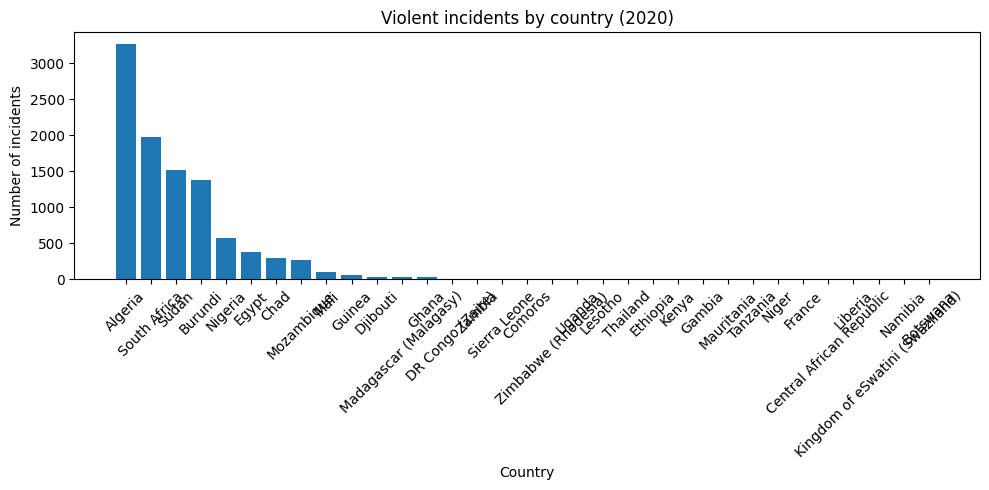

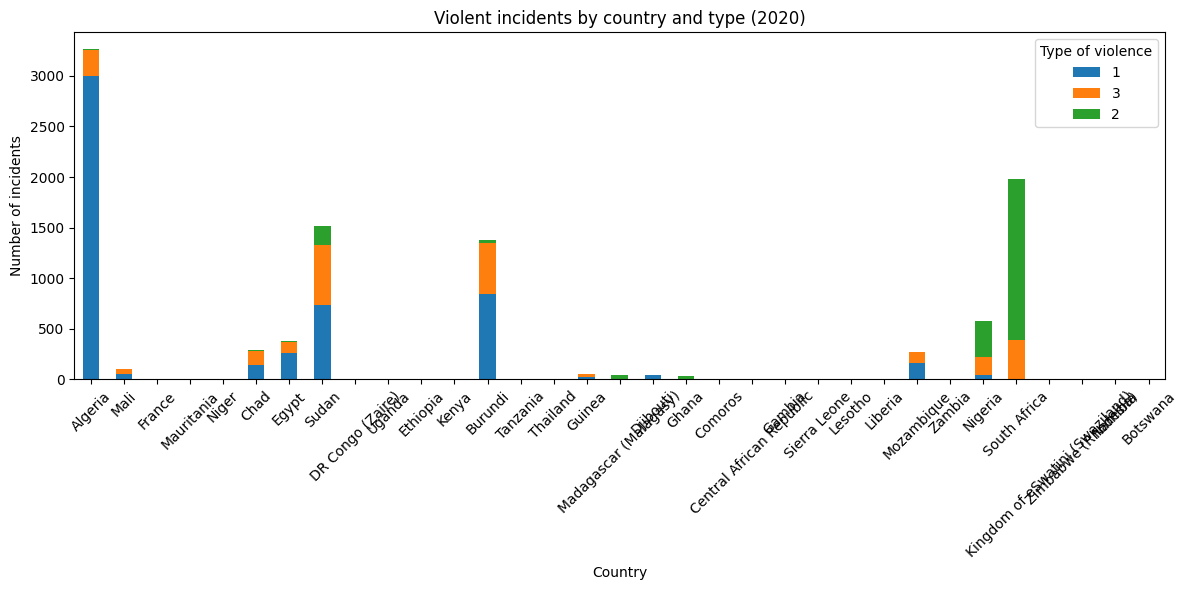

In [42]:
# insert code below
df = pd.DataFrame(all_events)

# Look at the data
print(df.head())
print(df.columns)

# Count number of incidents per country
country_counts = df["country"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(country_counts.index, country_counts.values)

plt.title("Violent incidents by country (2020)")
plt.xlabel("Country")
plt.ylabel("Number of incidents")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Get unique countries and violence types
countries = df["country"].unique()
violence_types = df["type_of_violence"].unique()

# Create an empty table
counts = {}

for vtype in violence_types:
    counts[vtype] = []

    for country in countries:
        number = len(
            df[(df["country"] == country) &
               (df["type_of_violence"] == vtype)]
        )
        counts[vtype].append(number)

# Convert to DataFrame
counts_df = pd.DataFrame(counts, index=countries)

# Plot stacked bar chart
counts_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Violent incidents by country and type (2020)")
plt.xlabel("Country")
plt.ylabel("Number of incidents")
plt.legend(title="Type of violence")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



**Exercise 4**

In [ ]:
# insert code below
